# TEMPORAL VELOCITY/ Central Velocity (First Derivatives)

## 1- Velocity

## $ V_n = \frac{d_{yn}}{d_t} $ =>
## $ V_n = \frac{y_{n} - y_{n-1}}{d_t} $

## 2- Central Velocity

## $ V_n = \frac{y_{n+1} - y_{n-1}}{2 \times d_t} $

In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

In [3]:
sr = 8000
directory = 'test_healthy_voice.wav'

audio, sr = librosa.load(directory, sr = sr, mono=True)

audio

array([ 0.01015559,  0.09465139,  0.18256481, ..., -0.22696644,
       -0.13908541, -0.04302341], dtype=float32)

In [6]:
def temporal_velocity(audio, sr):

    delta_t= 1/sr

    Vn = np.zeros_like(audio)
    for n in range(1, len(audio)-1):
        Vn[n] = (audio[n+1]-audio[n-1])/(2 * delta_t)
    Vn[0] = (audio[1]-audio[0])/delta_t
    Vn[-1] = (audio[-1]-audio[-2])/delta_t

    return Vn
        
        

In [7]:
central_velocity= temporal_velocity(audio, sr)

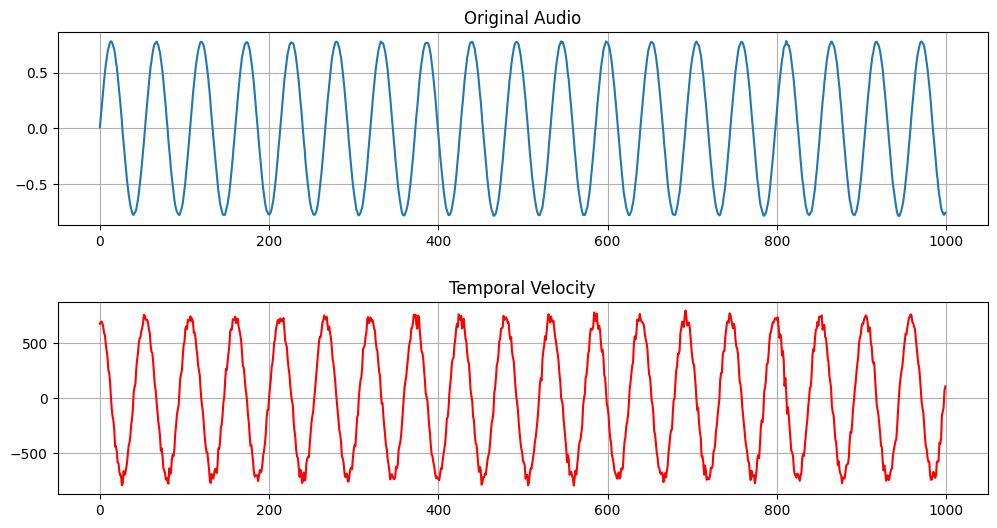

In [8]:
plt.figure(figsize=(12,6))
plt.subplot(211)
plt.plot(audio[:1000])
plt.title("Original Audio")
plt.grid(True)


plt.subplot(212)
plt.plot(central_velocity[:1000], color='red')
plt.title("Temporal Velocity")
plt.grid(True)




plt.subplots_adjust(hspace=0.4)
plt.show()

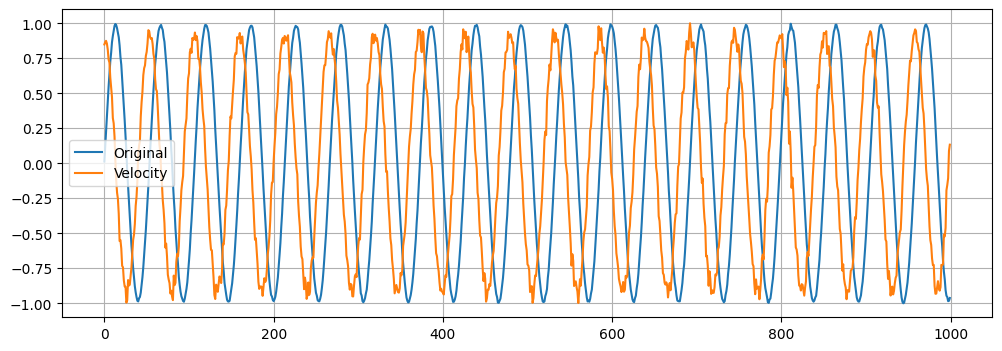

In [9]:
audio_norm = audio[:1000]/np.max(np.abs(audio[:1000]))
vel_norm= central_velocity[:1000]/np.max(np.abs(central_velocity[:1000]))

plt.figure(figsize=(12, 4))
plt.plot(audio_norm[:1000], label='Original')
plt.plot(vel_norm[:1000], label='Velocity')
plt.legend()
plt.grid(True)
plt.show()

## Vectorized Version

In [10]:
def first_der(audio, sr):

    dt = 1/sr

    v = np.zeros_like(audio)
    v[1:-1]= (audio[2:] - audio[:-2])/(2*dt)
    v[0] = (audio[1] - audio[0])/dt
    v[-1] = (audio[-1] - audio[-2])/dt

    return v

In [12]:
print("Vectorized: ",first_der(audio, sr))
print("Normal: ", central_velocity)

Vectorized:  [675.9664  689.63684 696.5239  ... 698.31964 735.7721  768.496  ]
Normal:  [675.9664  689.63684 696.5239  ... 698.31964 735.7721  768.496  ]
